In [2]:
import coderdata as cd
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [3]:
data_name = 'ccle'
data_path = '../data/Cancer/coderdata/'
cd.download(name=data_name, local_path=data_path)
data = cd.load(name=data_name, local_path=data_path)

Downloaded 'https://ndownloader.figshare.com/files/51830555' to '../data/Cancer/coderdata/ccle_proteomics.csv.gz'
Downloaded 'https://ndownloader.figshare.com/files/51830558' to '../data/Cancer/coderdata/ccle_mutations.csv.gz'
Downloaded 'https://ndownloader.figshare.com/files/51830591' to '../data/Cancer/coderdata/ccle_copy_number.csv.gz'
Downloaded 'https://ndownloader.figshare.com/files/51830627' to '../data/Cancer/coderdata/ccle_experiments.tsv.gz'
Downloaded 'https://ndownloader.figshare.com/files/51830654' to '../data/Cancer/coderdata/ccle_transcriptomics.csv.gz'
Downloaded 'https://ndownloader.figshare.com/files/51830669' to '../data/Cancer/coderdata/ccle_drugs.tsv.gz'
Downloaded 'https://ndownloader.figshare.com/files/51830726' to '../data/Cancer/coderdata/ccle_samples.csv'
Downloaded 'https://ndownloader.figshare.com/files/51830741' to '../data/Cancer/coderdata/ccle_drug_descriptors.tsv.gz'
Downloaded 'https://ndownloader.figshare.com/files/51966266' to '../data/Cancer/coderda

Importing raw data ...
Importing 'copy_number' from ../data/Cancer/coderdata/ccle_copy_number.csv.gz ... DONE
Importing 'experiments' from ../data/Cancer/coderdata/ccle_experiments.tsv.gz ... DONE
Importing 'proteomics' from ../data/Cancer/coderdata/ccle_proteomics.csv.gz ... DONE
Importing 'mutations' from ../data/Cancer/coderdata/ccle_mutations.csv.gz ... DONE
Importing 'genes' from ../data/Cancer/coderdata/genes.csv.gz ... DONE
Importing 'drug_descriptors' from ../data/Cancer/coderdata/ccle_drug_descriptors.tsv.gz ... DONE
Importing 'transcriptomics' from ../data/Cancer/coderdata/ccle_transcriptomics.csv.gz ... DONE
Importing 'samples' from ../data/Cancer/coderdata/ccle_samples.csv ... DONE
Importing 'drugs' from ../data/Cancer/coderdata/ccle_drugs.tsv.gz ... DONE
Importing raw data ... DONE


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import pandas as pd
import numpy as np
import torch

In [6]:
def df_hist(values_df: pd.DataFrame) -> None:
    # Plot histogram
    plt.figure(figsize=(10, 6))
    plt.hist(values_df, bins=100, color='skyblue', edgecolor='black', log=True)
    
    # Labels and title
    plt.xlabel("Variance")
    plt.ylabel("Frequency (log scale)")
    plt.title("Distribution of Variance Across Values")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.show()    

In [7]:
def var_filter(feature_df: pd.DataFrame, var_l_thres: float=0., var_h_thres: float=1e10) -> pd.DataFrame:
    print(f"total input {len(feature_df.columns)}")
    var_vals = feature_df.var()
    df_hist(var_vals)

    f_nontrivial = feature_df.loc[:, (var_vals > var_l_thres) & (var_vals < var_h_thres)]
    print(f"nontrivial features {len(f_nontrivial.columns)}")
    new_var_vals = f_nontrivial.var()
    df_hist(new_var_vals)
    return f_nontrivial

total input 19356


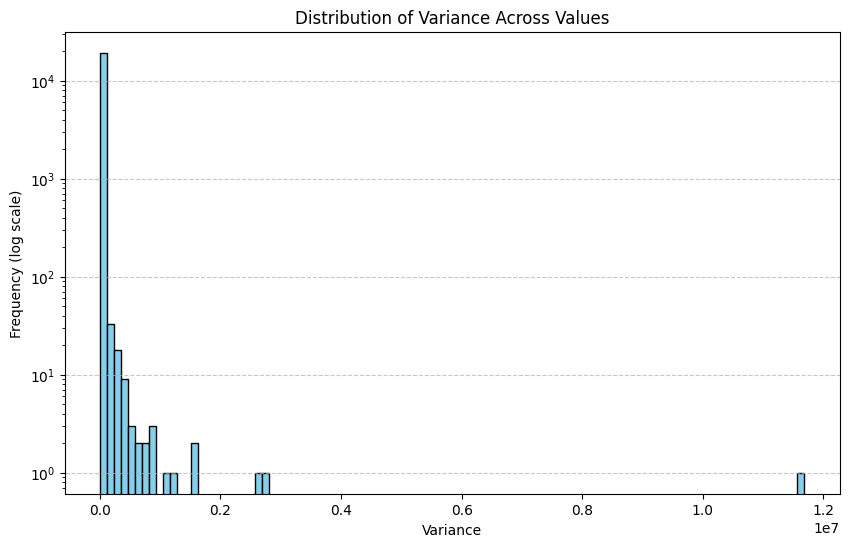

nontrivial features 13042


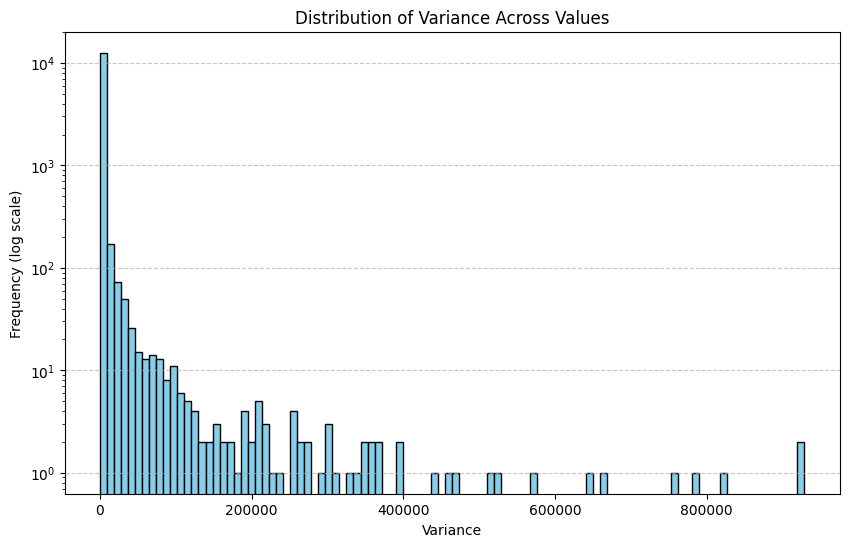

In [8]:
transcriptomics = data.format(data_type='transcriptomics')
t_var_l_thres = 10
t_var_h_thres = 1e6

transcriptomics_nontrivial = var_filter(transcriptomics, t_var_l_thres, t_var_h_thres)

total input 19202


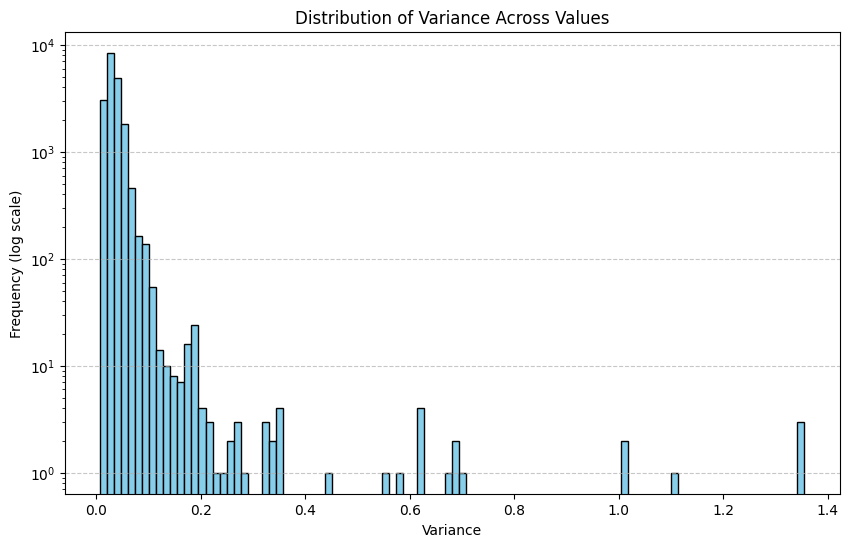

nontrivial features 19202


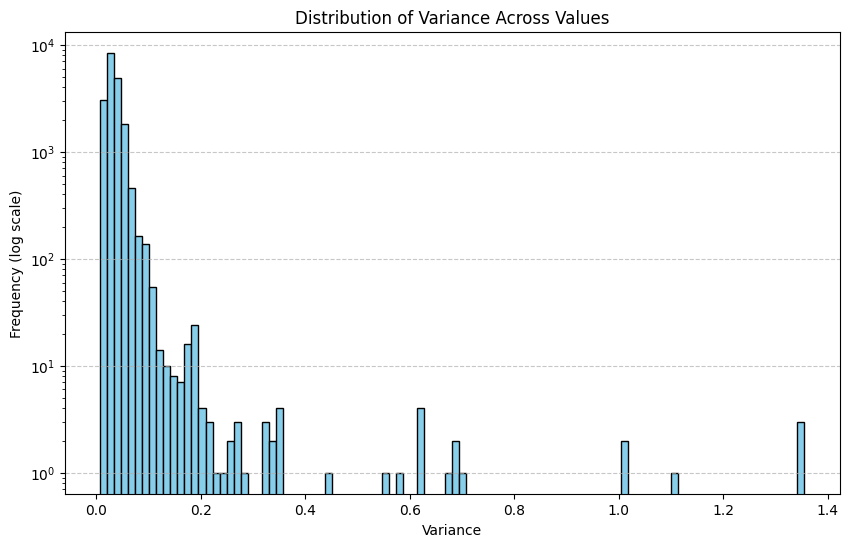

In [12]:
copy_number = data.format(data_type="copy_number", copy_call=False)
c_l_thres = 0
c_h_thres = 2

copy_number_nontrivial = var_filter(copy_number, c_l_thres, c_h_thres)

total input 12349


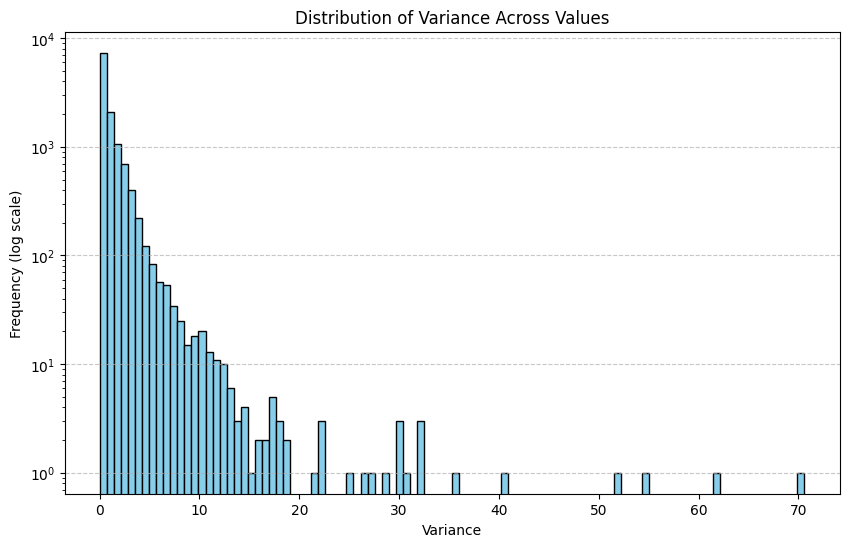

nontrivial features 12349


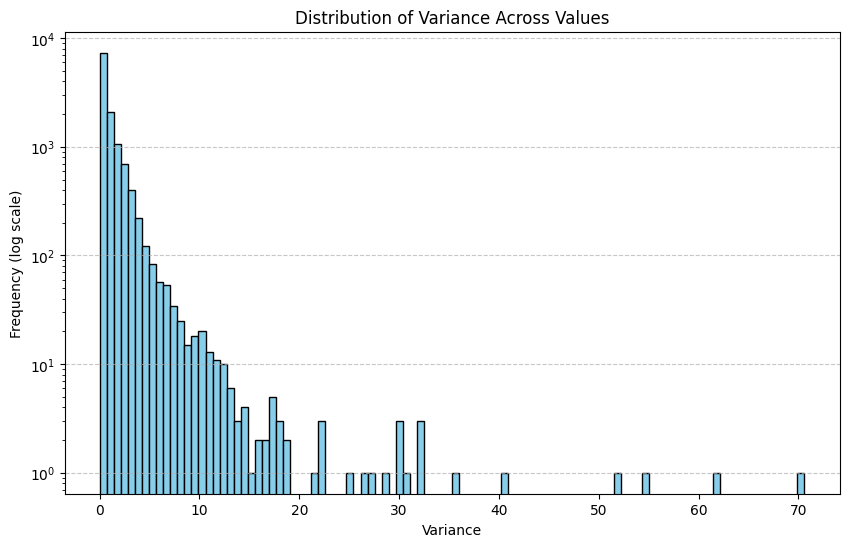

In [13]:
proteomics = data.format(data_type="proteomics")
p_l_thres = 0
p_h_thres = 100

proteomics_nontrivial = var_filter(proteomics, p_l_thres, p_h_thres)

For mutation type Missense_Mutation
total input 18660


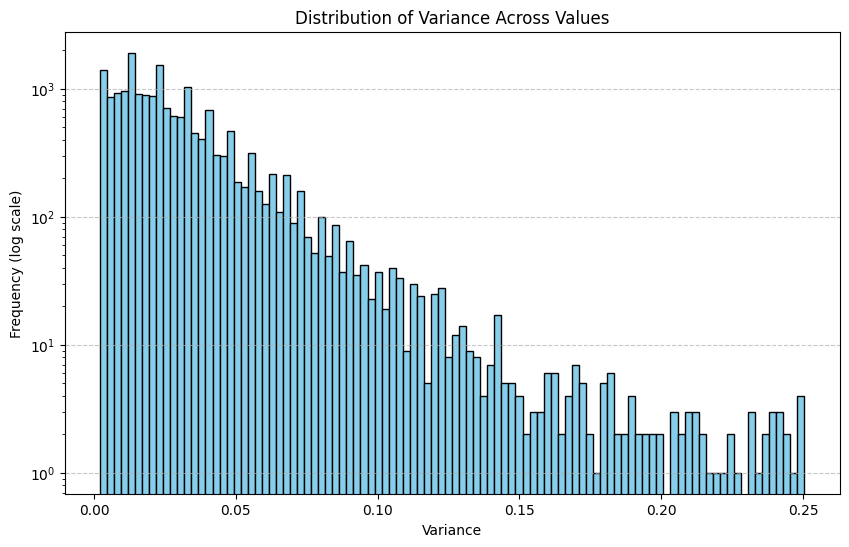

nontrivial features 18660


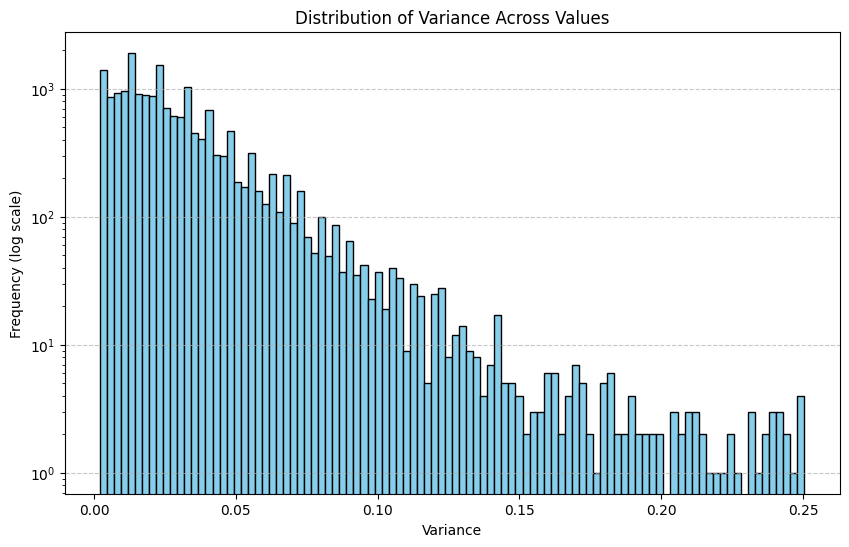

For mutation type Silent
total input 16948


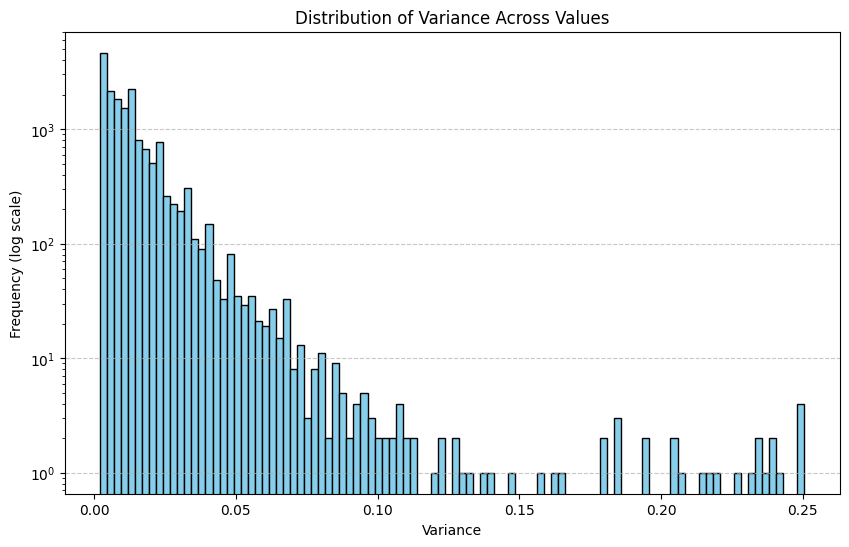

nontrivial features 16948


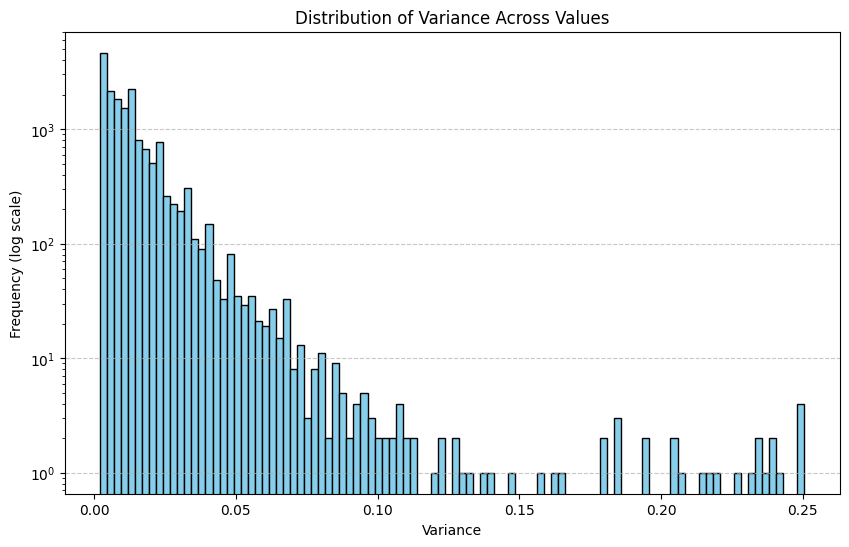

For mutation type In_Frame_Ins
total input 323


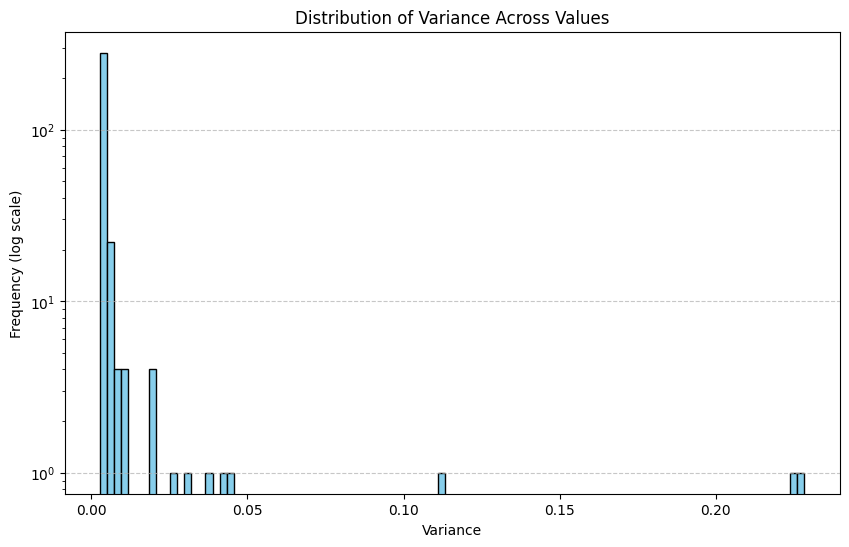

nontrivial features 323


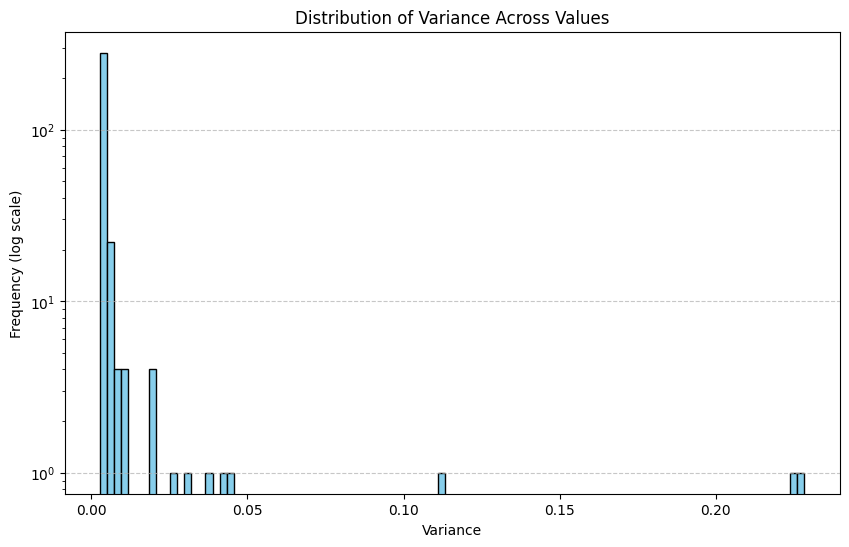

For mutation type Splice_Site
total input 11450


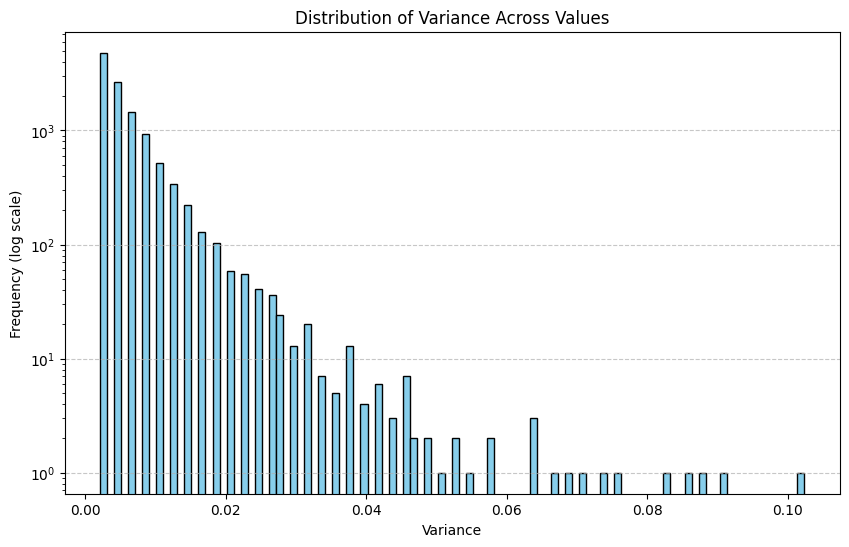

nontrivial features 11450


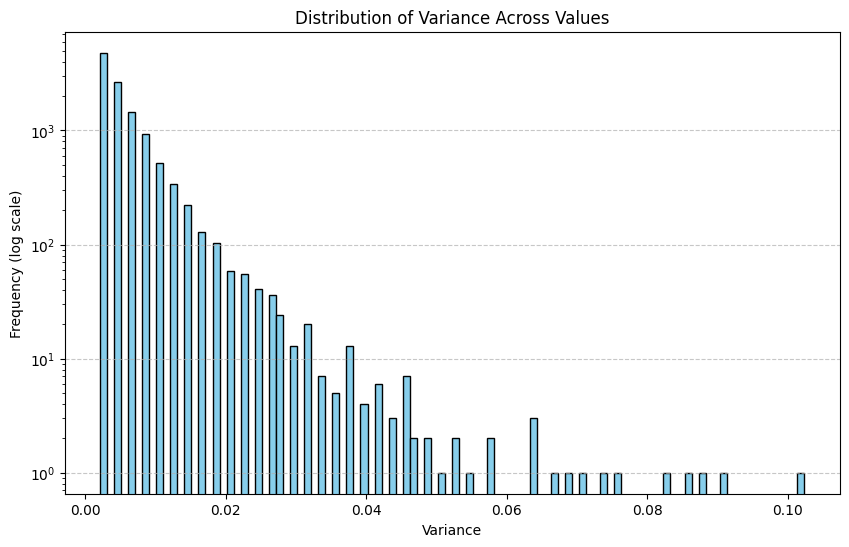

For mutation type Nonsense_Mutation
total input 8286


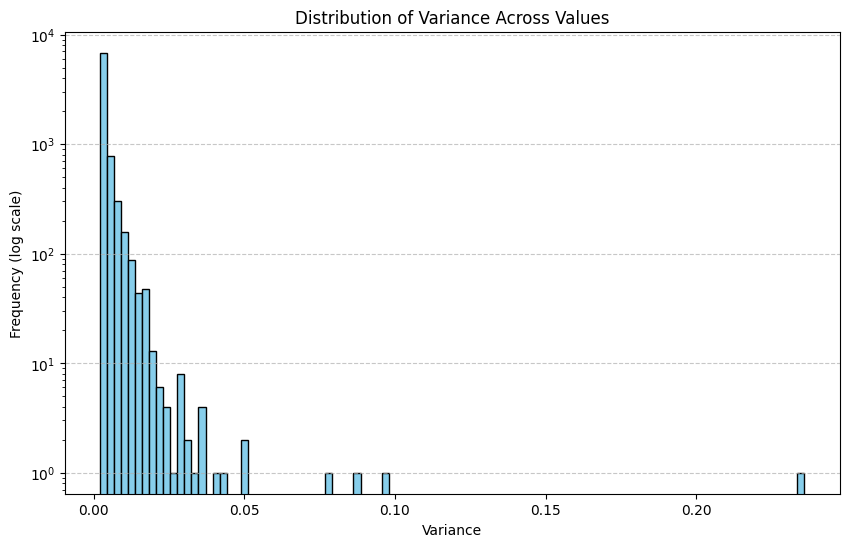

nontrivial features 8286


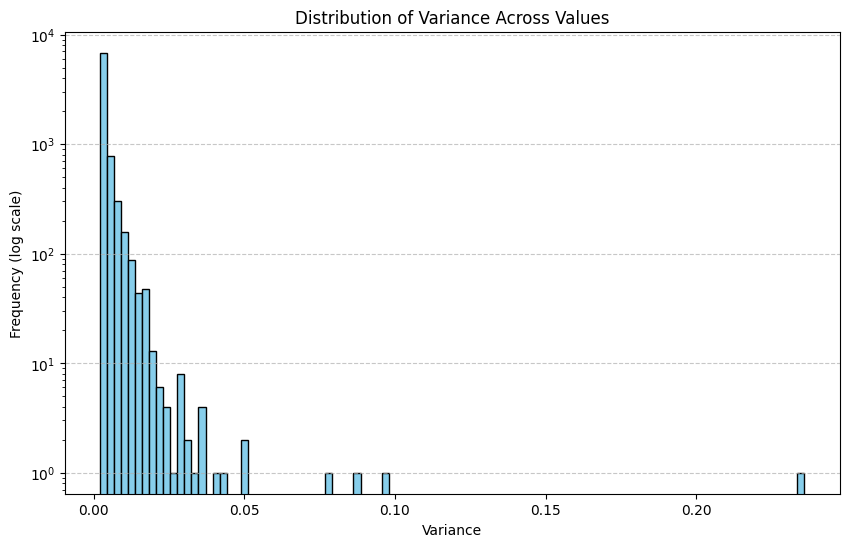

For mutation type Frame_Shift_Del
total input 8895


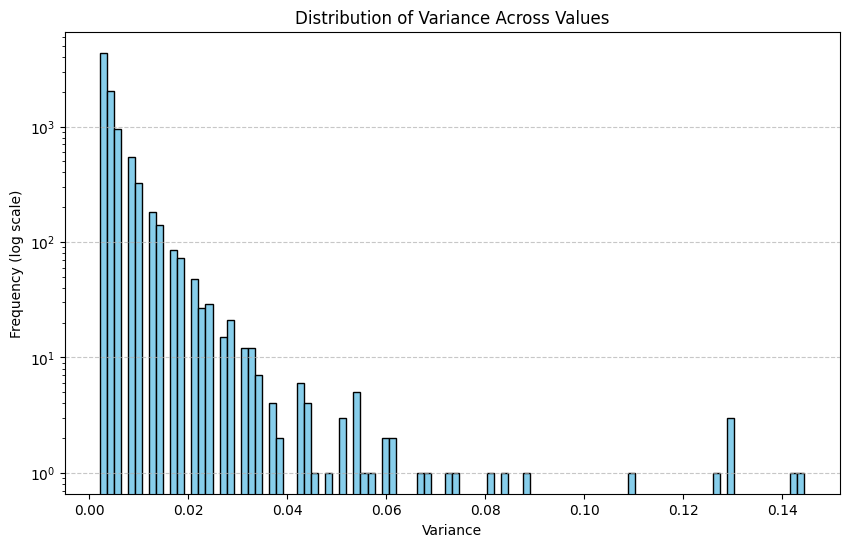

nontrivial features 8895


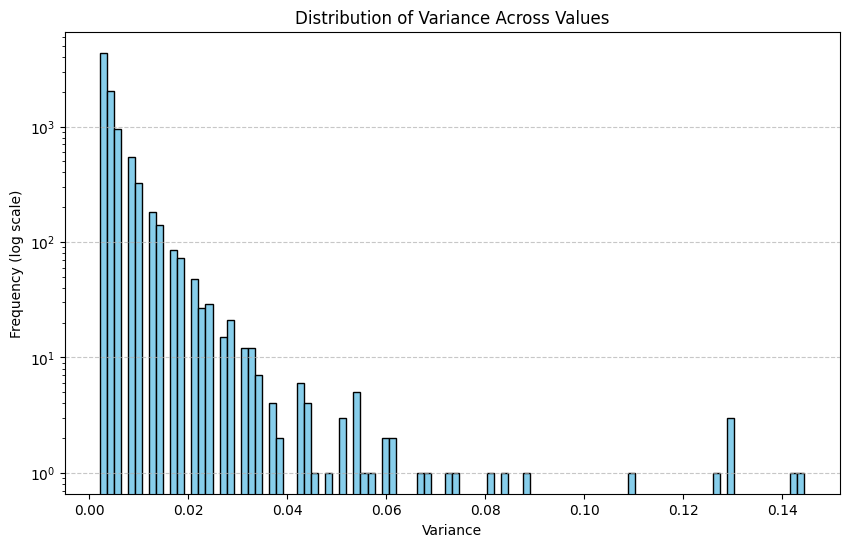

For mutation type Nonstop_Mutation
total input 320


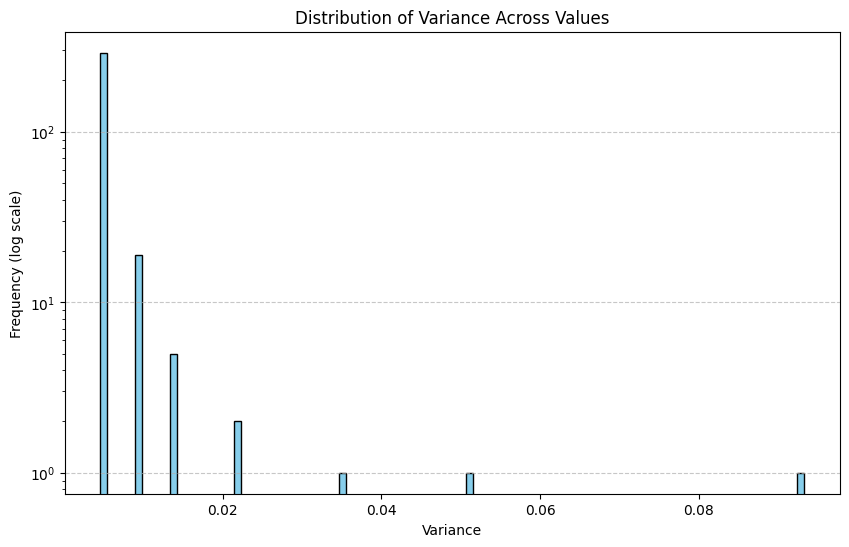

nontrivial features 320


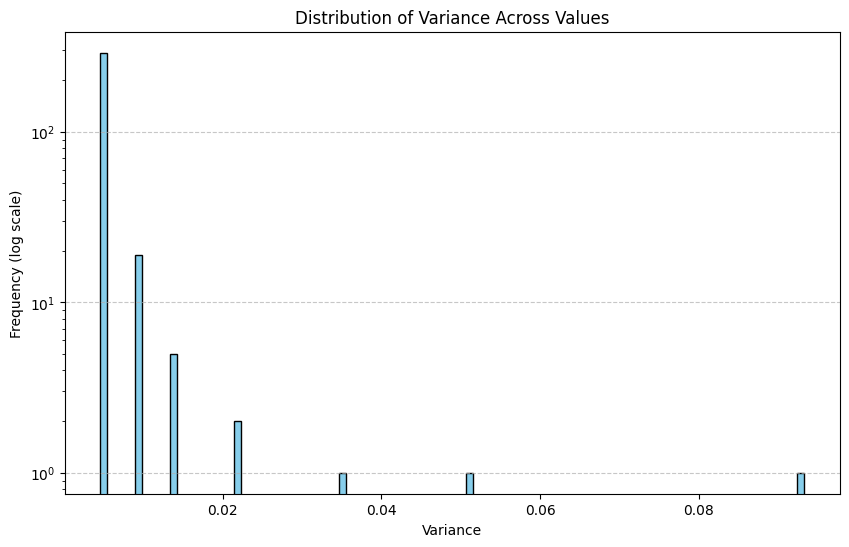

For mutation type Start_Codon_SNP
total input 485


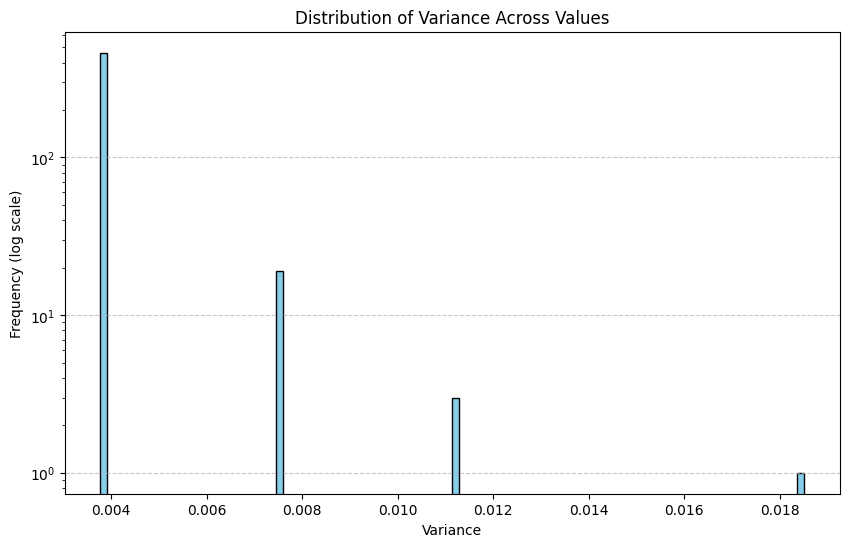

nontrivial features 485


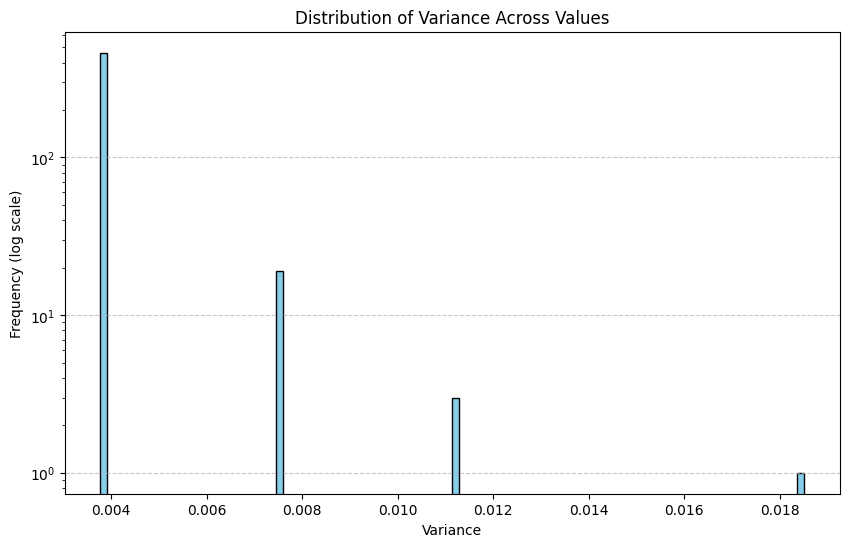

For mutation type In_Frame_Del
total input 2037


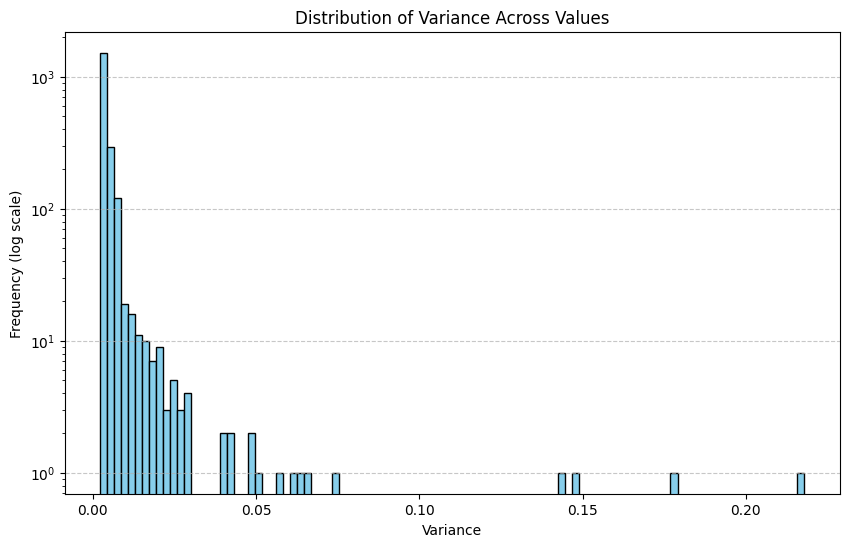

nontrivial features 2037


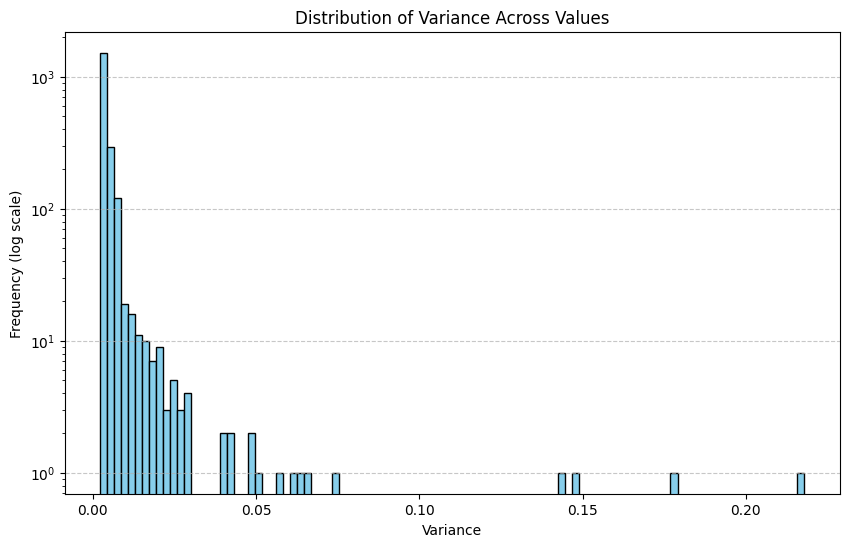

For mutation type Frame_Shift_Ins
total input 4189


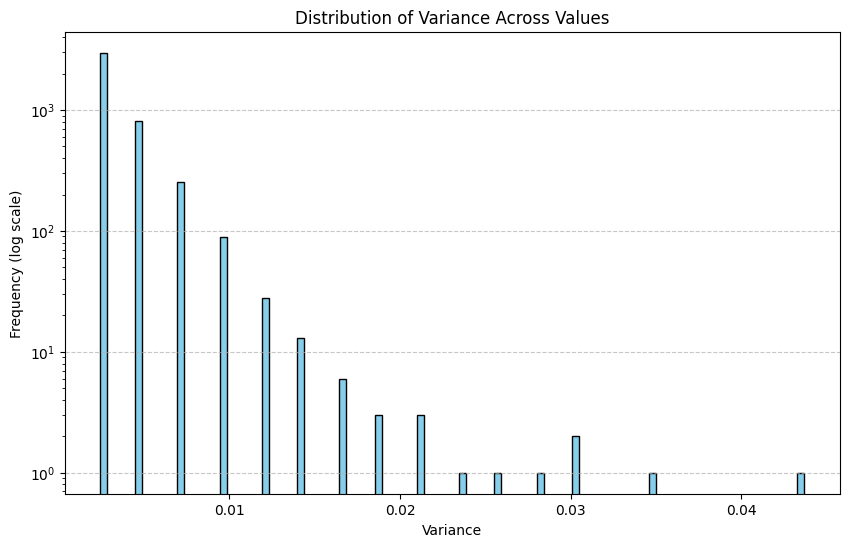

nontrivial features 4189


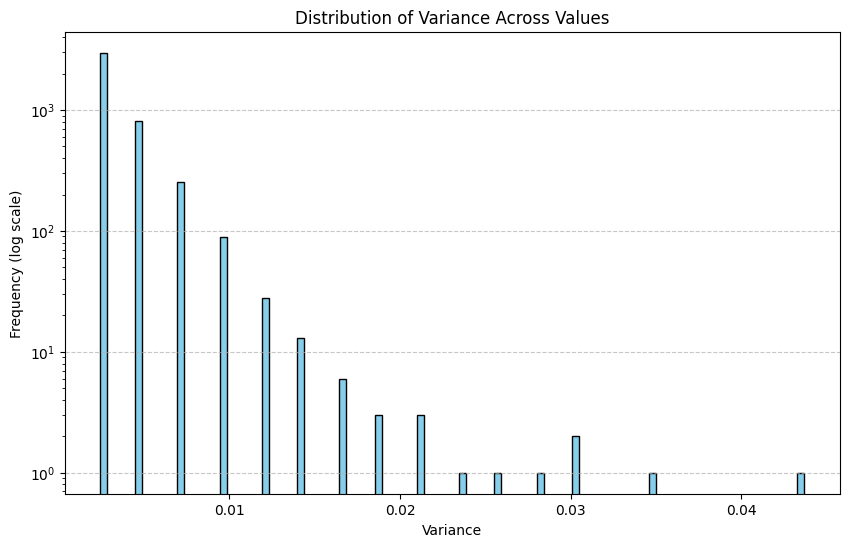

For mutation type Start_Codon_Ins
total input 7


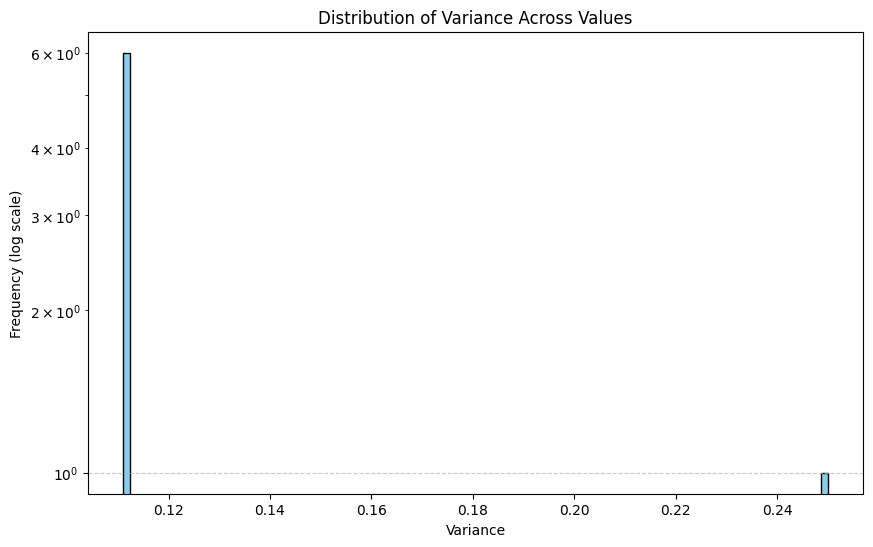

nontrivial features 7


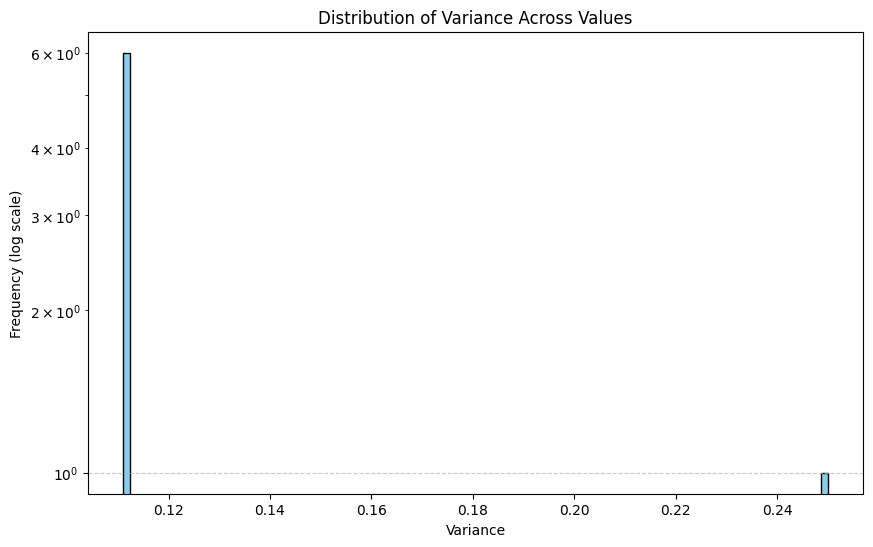

For mutation type Intron
total input 15273


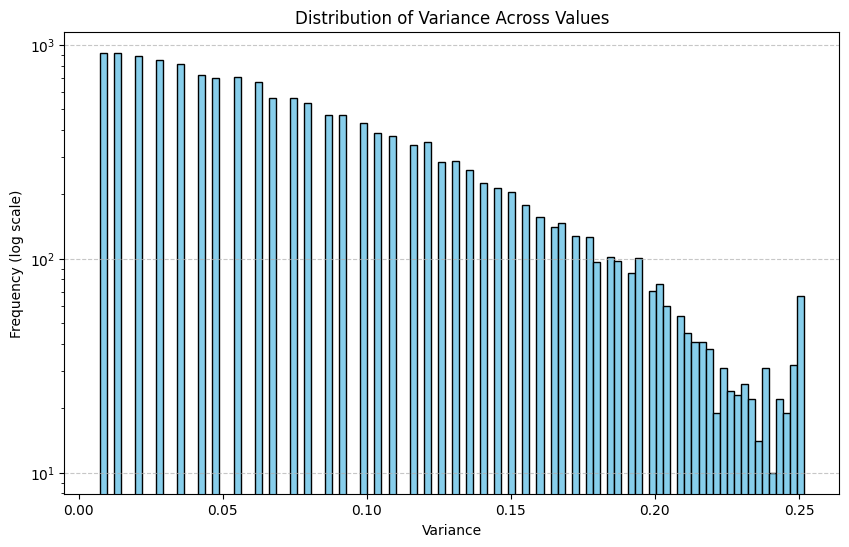

nontrivial features 15273


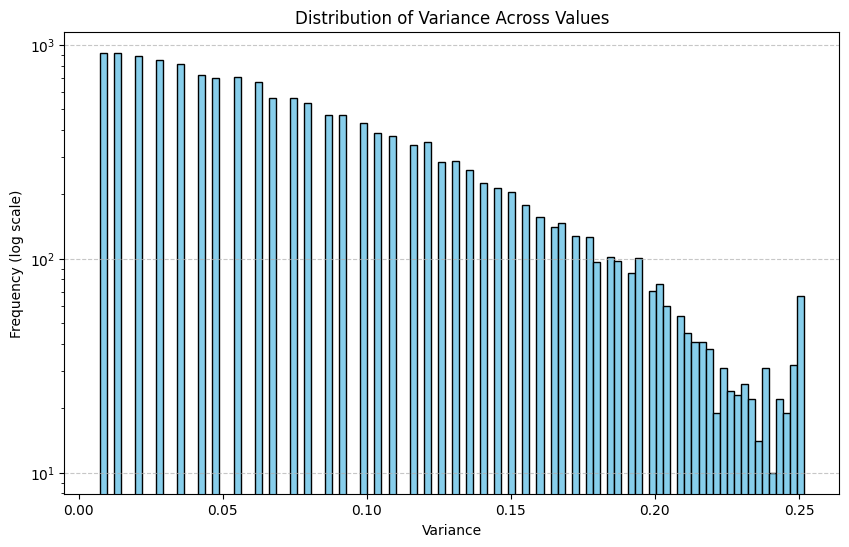

For mutation type 3'UTR
total input 8673


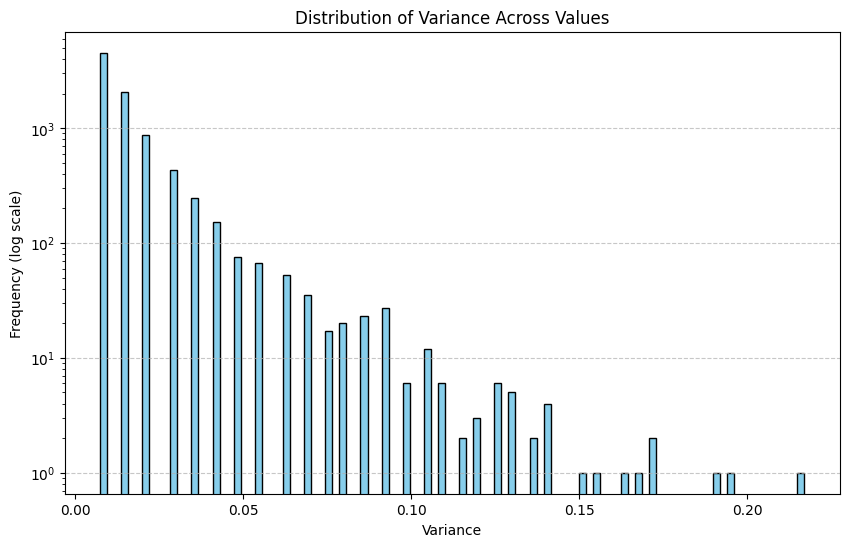

nontrivial features 8673


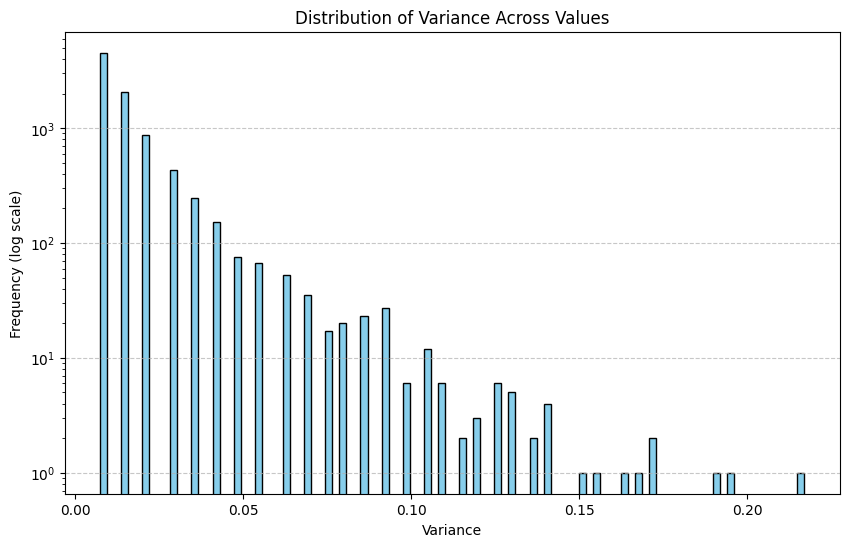

For mutation type 5'Flank
total input 3322


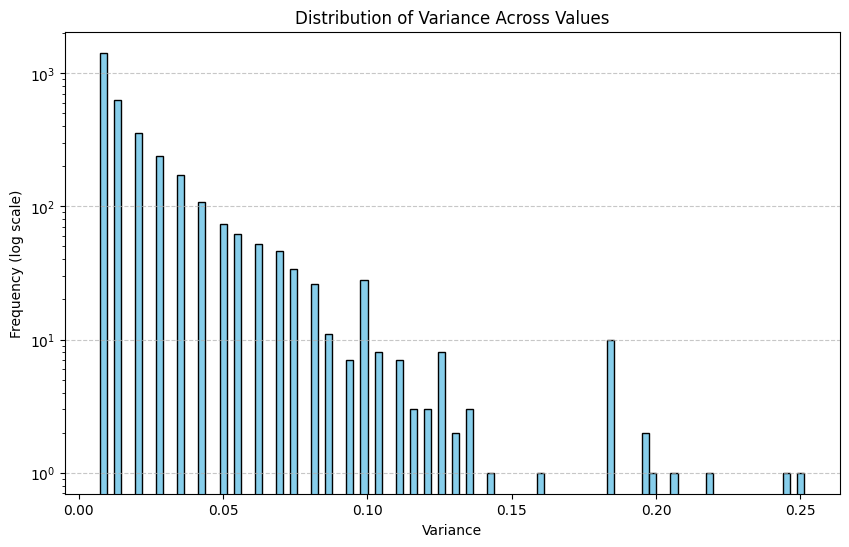

nontrivial features 3322


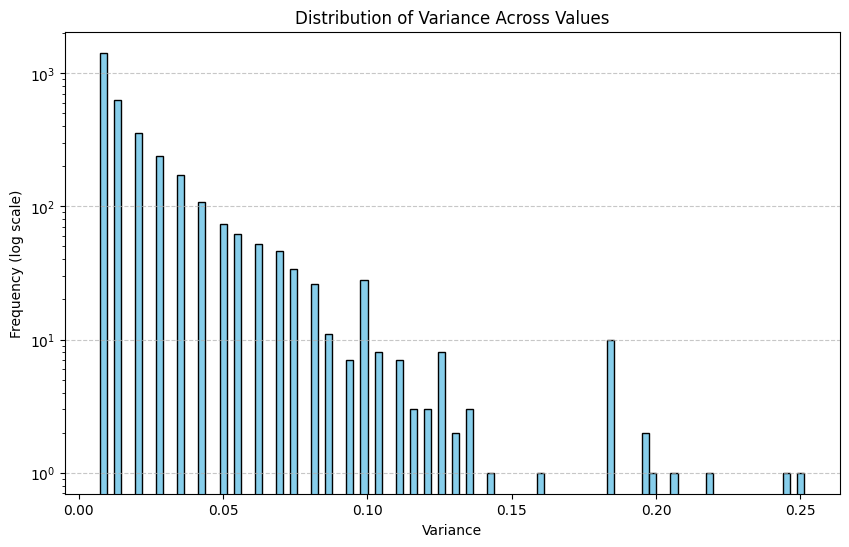

For mutation type 5'UTR
total input 4928


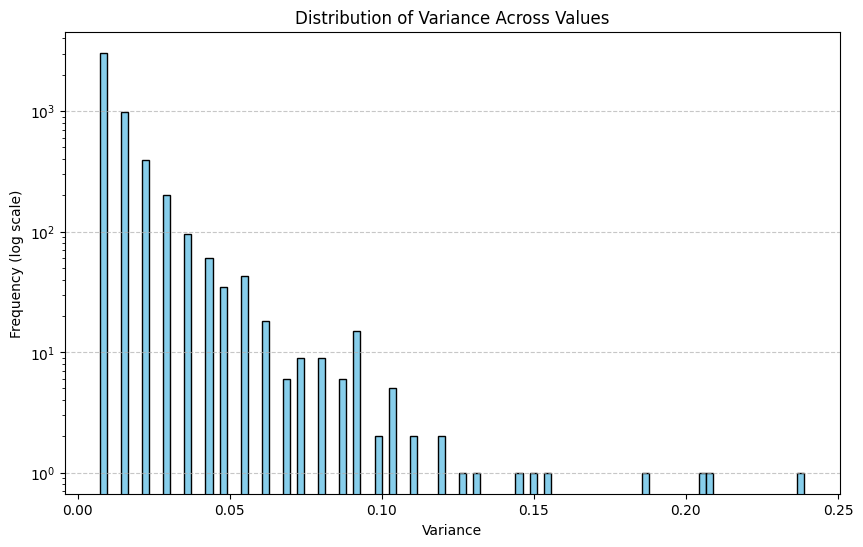

nontrivial features 4928


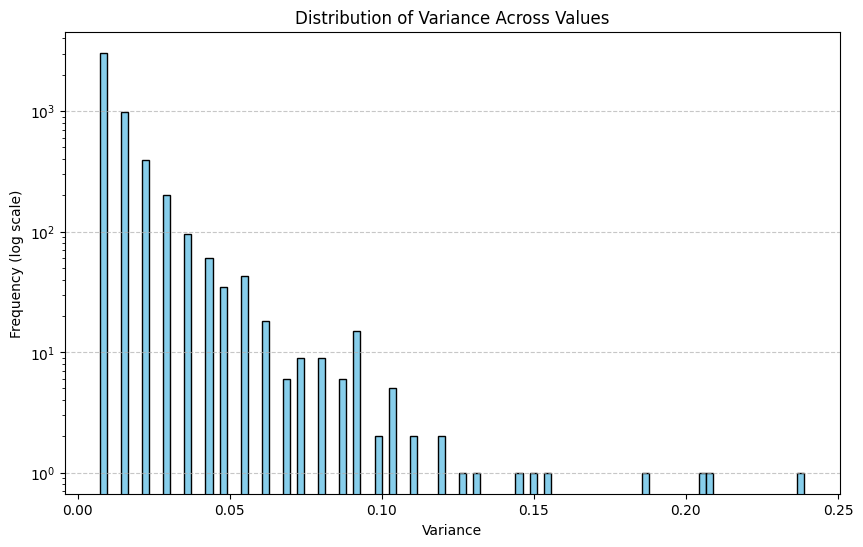

For mutation type Start_Codon_Del
total input 203


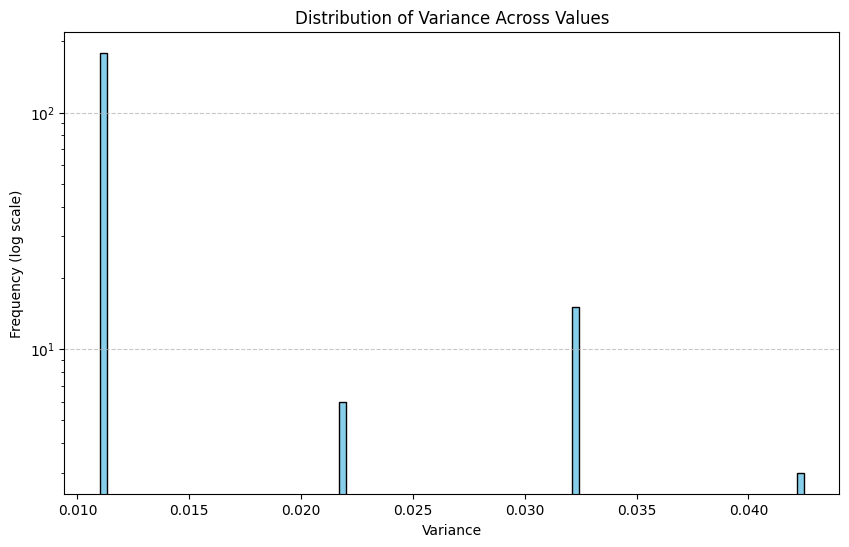

nontrivial features 203


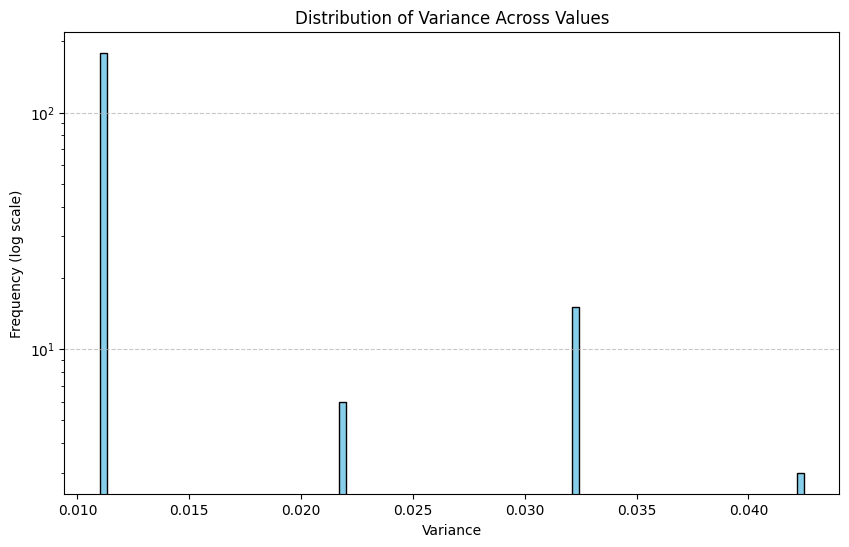

For mutation type Translation_Start_Site
total input 203


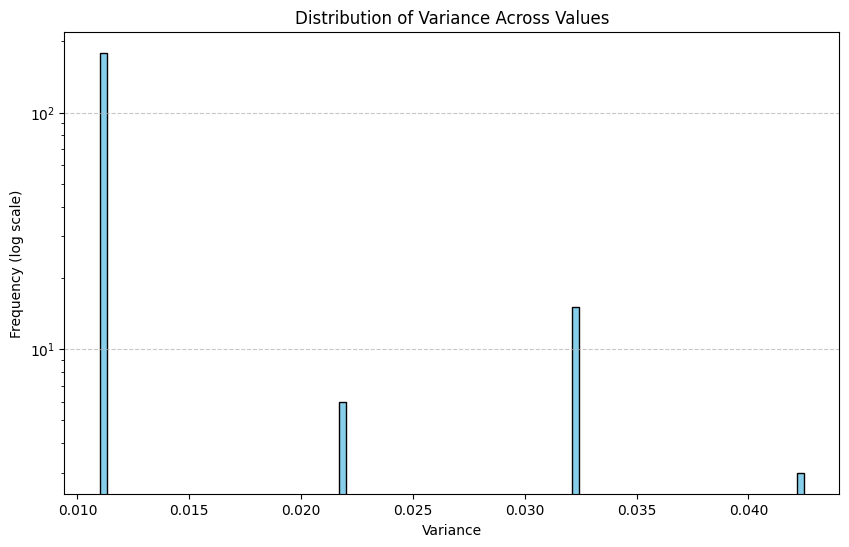

nontrivial features 203


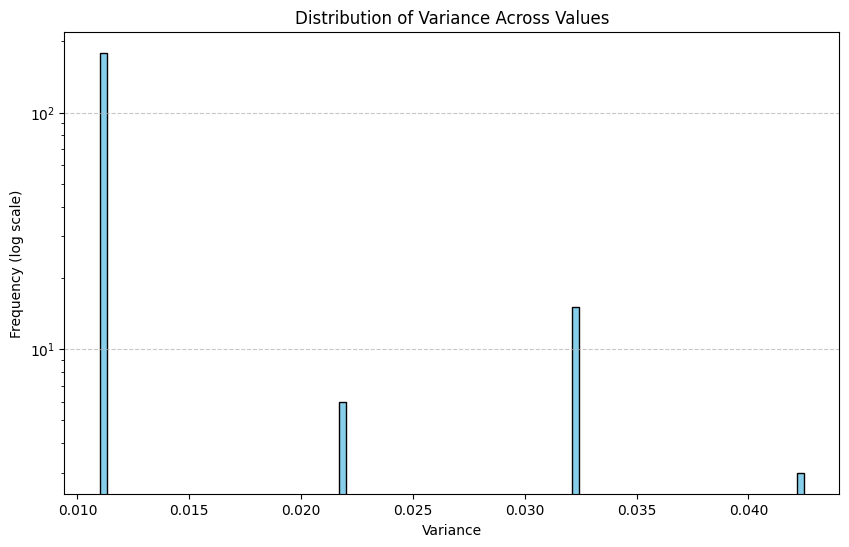

For mutation type Stop_Codon_Del
total input 103


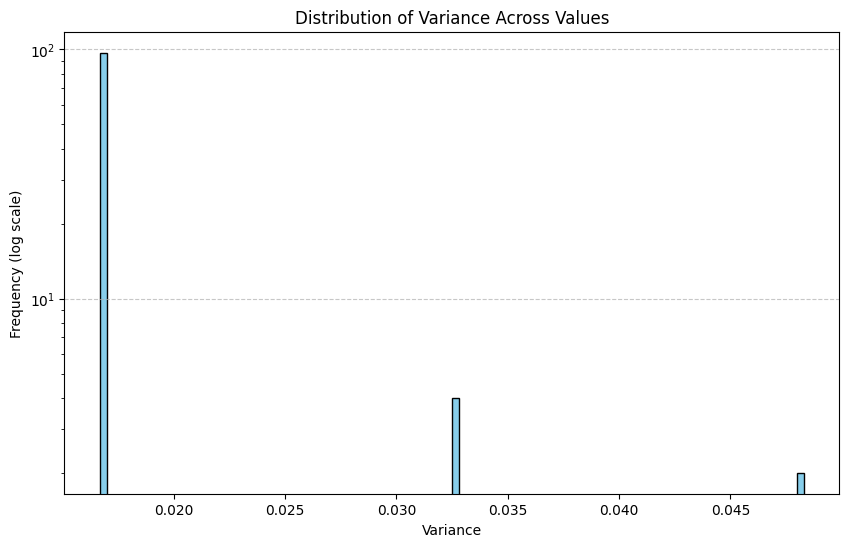

nontrivial features 103


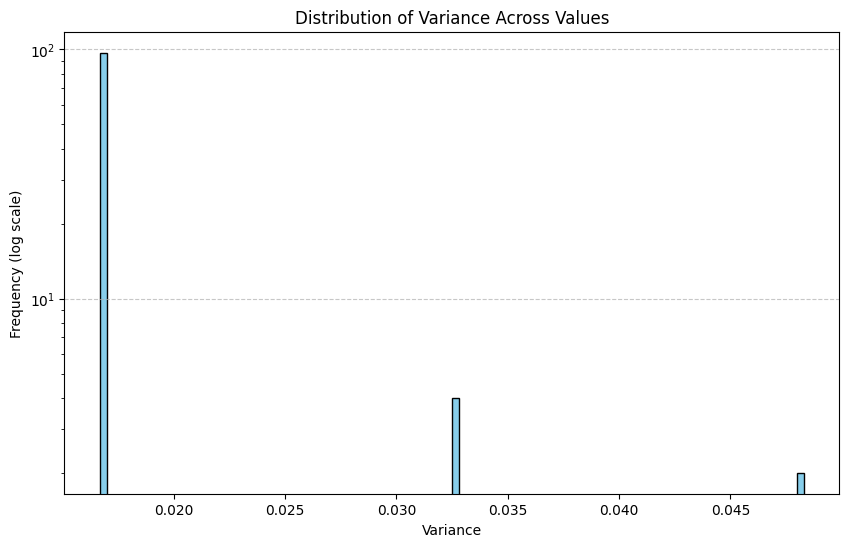

In [11]:
mutation_nontrivial_dict = {}
m_l_thres = 0
m_h_thres = 1

for mut_type in data.mutations.variant_classification.unique():
    print(f"For mutation type {mut_type}")
    mutation_nontrivial_dict[mut_type] = var_filter(data.format(data_type='mutations', mutation_type=mut_type), var_l_thres=m_l_thres, var_h_thres=m_h_thres)

In [14]:
print("t", len(transcriptomics_nontrivial.index))
print("c", len(copy_number_nontrivial.index))
print("p", len(proteomics_nontrivial.index))
for key, value in mutation_nontrivial_dict.items():
    print(key, len(value.index))

t 475
c 495
p 252
Missense_Mutation 485
Silent 485
In_Frame_Ins 365
Splice_Site 485
Nonsense_Mutation 485
Frame_Shift_Del 475
Nonstop_Mutation 222
Start_Codon_SNP 266
In_Frame_Del 460
Frame_Shift_Ins 416
Start_Codon_Ins 9
Intron 137
3'UTR 137
5'Flank 136
5'UTR 137
Start_Codon_Del 91
Translation_Start_Site 91
Stop_Codon_Del 60


In [36]:
def align_df(ref_df:pd.DataFrame, df: pd.DataFrame, filling_value: float=0) -> pd.DataFrame:
    # Assuming 'df' is your subset DataFrame and 'ref_df' is your reference DataFrame
    
    # Step 1: Identify the missing row indices
    missing_indices = ref_df.index.difference(df.index)
    
    # Step 2: Create a DataFrame with zeros for the missing indices
    zeros_df = pd.DataFrame(filling_value, index=missing_indices, columns=df.columns)
    
    # Step 3: Concatenate the original df with the zero-filled rows
    df_with_filling = pd.concat([df, zeros_df])
    
    # Step 4: Reorder the DataFrame by index to ensure correct order
    df_with_filling = df_with_filling.sort_index()
    
    # Now 'df_with_zeros' contains all the rows from 'ref_df' with missing rows filled with zeros
    return df_with_filling

In [56]:
def extract_row(df_ref, sample_id):
    if sample_id in df_ref.index:
        feature = df_ref.loc[sample_id].to_numpy()
        feature[np.isnan(feature)] = 0
        id = sample_id
    else:
        feature = np.zeros((df_ref.shape[1],))   
        id = -1
    return feature, id

In [57]:
def repre_drug(drug_ids, drug_embeds, d_id):
    d_idx = np.where(drug_ids == d_id)
    embed = drug_embeds[d_idx][0]
    return embed

In [58]:
megaMolBart = np.load('../data/Cancer/aggregation/megaMolBart_data.npz', allow_pickle=True)
drug_ids = megaMolBart['improve_drug_id']
drug_embeds = megaMolBart['embed']

In [59]:
experiments = data.experiments[data.experiments["dose_response_metric"]=="fit_auc"]
mf = {key: [] for key in mutation_nontrivial_dict.keys()}
tf = []
pf = []
cf = []
mss = {key: [] for key in mutation_nontrivial_dict.keys()}
tss = []
pss = []
css = []
drugf = []
resp = []

for index, row in experiments.iterrows():
    improve_sample_id = int(row["improve_sample_id"])
    # print(improve_sample_id)
    # print("transcriptomics")
    trans, t_id = extract_row(transcriptomics_nontrivial, improve_sample_id)
    tf.append(trans)
    tss.append(t_id)
    # print("copy number")
    copy, c_id = extract_row(copy_number_nontrivial, improve_sample_id)
    cf.append(copy)
    css.append(c_id)
    # print("proteomics")
    pro, p_id = extract_row(proteomics_nontrivial, improve_sample_id)
    pf.append(pro)
    pss.append(p_id)
    # print("mutation")
    for mut_type in mutation_nontrivial_dict.keys():
        # print(mut_type)
        mut, m_id = extract_row(mutation_nontrivial_dict[mut_type], improve_sample_id)
        mf[mut_type].append(mut)
        mss[mut_type].append(m_id)

    drug_id = row["improve_drug_id"]
    drug = repre_drug(drug_ids, drug_embeds, drug_id)
    drugf.append(drug)

    resp.append(row["dose_response_metric"])
    if index % 1000 == 0:
        print(f"Processed {index+1} samples")

Processed 1 samples
Processed 1001 samples
Processed 2001 samples
Processed 3001 samples
Processed 4001 samples
Processed 5001 samples
Processed 6001 samples
Processed 7001 samples
Processed 8001 samples
Processed 9001 samples
Processed 10001 samples
Processed 11001 samples


In [60]:
def cat_cell_features(feature_types:list, features:list, sample_size: int) -> np.ndarray:
    """
    Concatenate features from different omics data types.
    """
    training_data = []
    for s_id in range(sample_size):
        cell_features = []
        for index, f_type in enumerate(feature_types):
            if f_type == "transcriptomics":
                cell_features.append(features[index][s_id])
            elif f_type == "copy_number":
                cell_features.append(features[index][s_id])
            elif f_type == "proteomics":
                cell_features.append(features[index][s_id])
            elif f_type == "mutation":
                for mut_type in features[index].keys():
                    cell_features.append(features[index][mut_type][s_id])
            else:
                raise ValueError(f"Unknown feature type: {f_type}")
        training_data.append(np.concatenate(cell_features, axis=0))
    return np.array(training_data)

In [61]:
X = cat_cell_features(
    feature_types=["transcriptomics", "copy_number", "proteomics", "mutation"],
    features=[tf, cf, pf, mf],
    sample_size=len(resp)
)
y = np.array(resp)

/home/dzhao268/anaconda3/envs/hdp/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


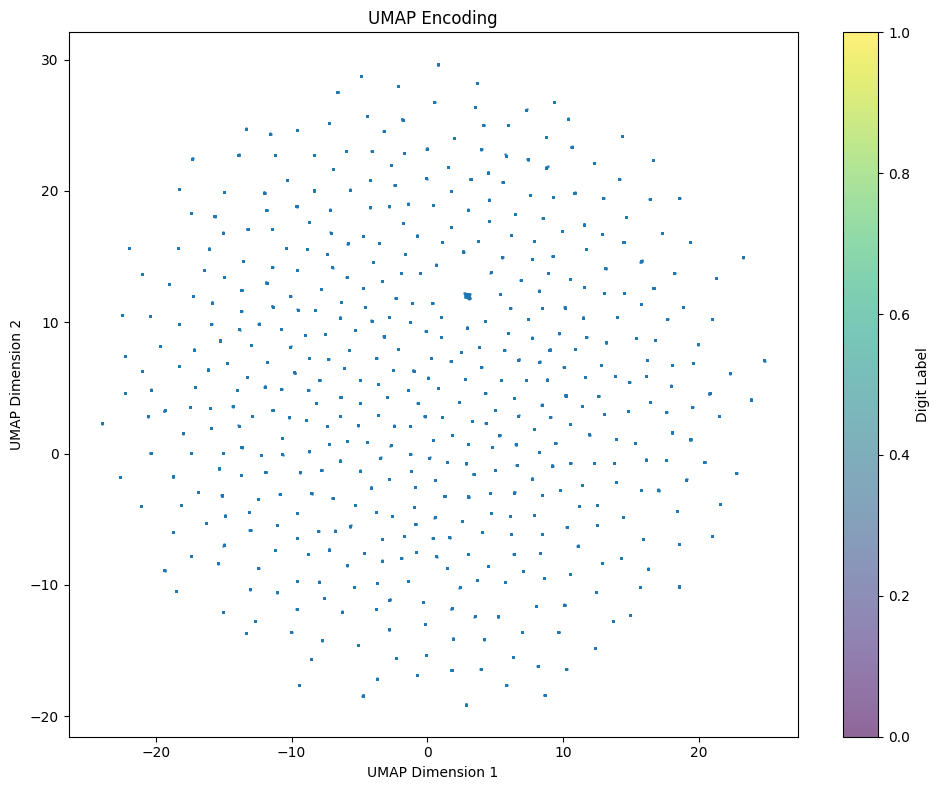

In [62]:
from umap import UMAP
import matplotlib.pyplot as plt
umap = UMAP()
# umap = UMAP(n_neighbors=5, min_dist=0.01, random_state=42)
# Fit and transform the data
X_train_umap = umap.fit_transform(X)

# Plot the results
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_train_umap[:, 0], X_train_umap[:, 1], cmap="Spectral", s=1, alpha=0.6)
plt.colorbar(scatter, label="Digit Label")
plt.title("UMAP Encoding")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
# Show the plot
plt.tight_layout()
plt.show()

/home/dzhao268/anaconda3/envs/hdp/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


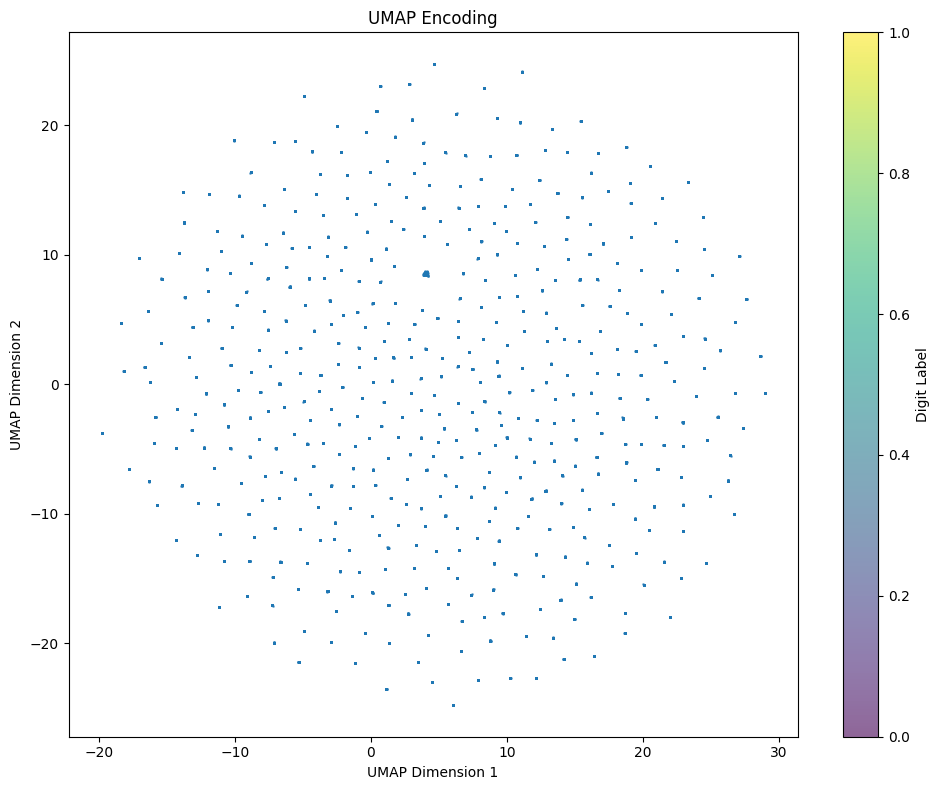

In [63]:
X = cat_cell_features(
    feature_types=["transcriptomics", "copy_number", "proteomics"],
    features=[tf, cf, pf],
    sample_size=len(resp)
)
y = np.array(resp)

from umap import UMAP
import matplotlib.pyplot as plt
umap = UMAP()
# umap = UMAP(n_neighbors=5, min_dist=0.01, random_state=42)
# Fit and transform the data
X_train_umap = umap.fit_transform(X)

# Plot the results
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_train_umap[:, 0], X_train_umap[:, 1], cmap="Spectral", s=1, alpha=0.6)
plt.colorbar(scatter, label="Digit Label")
plt.title("UMAP Encoding")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
# Show the plot
plt.tight_layout()
plt.show()

/home/dzhao268/anaconda3/envs/hdp/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


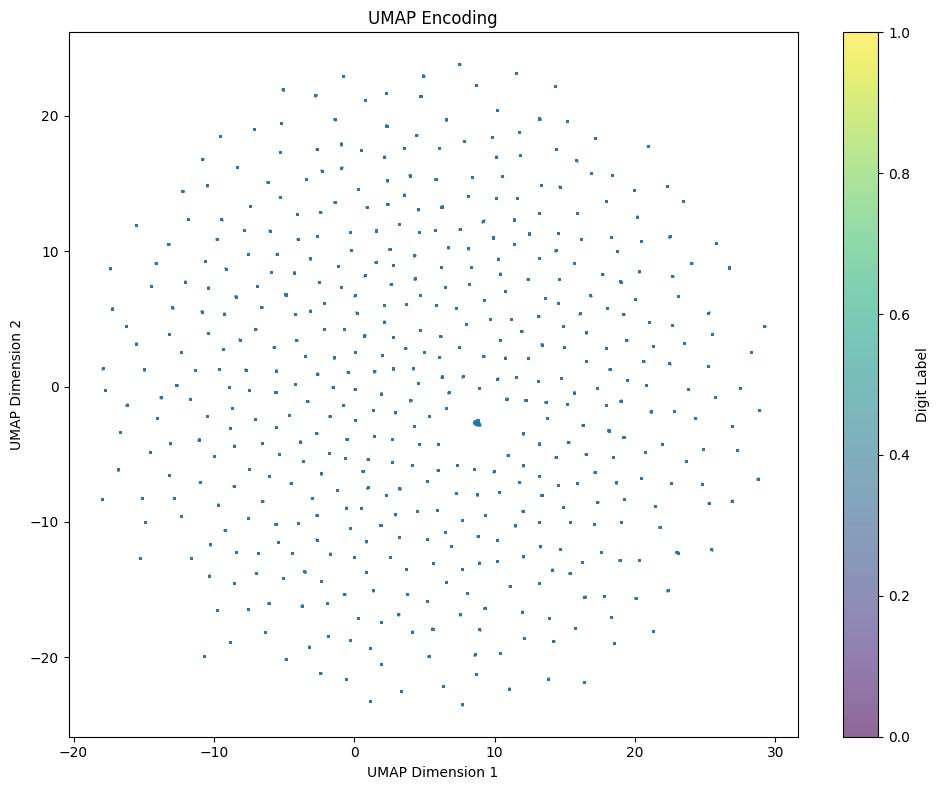

In [64]:
X = cat_cell_features(
    feature_types=["transcriptomics", "copy_number"],
    features=[tf, cf],
    sample_size=len(resp)
)
y = np.array(resp)

from umap import UMAP
import matplotlib.pyplot as plt
umap = UMAP()
# umap = UMAP(n_neighbors=5, min_dist=0.01, random_state=42)
# Fit and transform the data
X_train_umap = umap.fit_transform(X)

# Plot the results
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_train_umap[:, 0], X_train_umap[:, 1], cmap="Spectral", s=1, alpha=0.6)
plt.colorbar(scatter, label="Digit Label")
plt.title("UMAP Encoding")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
# Show the plot
plt.tight_layout()
plt.show()

/home/dzhao268/anaconda3/envs/hdp/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


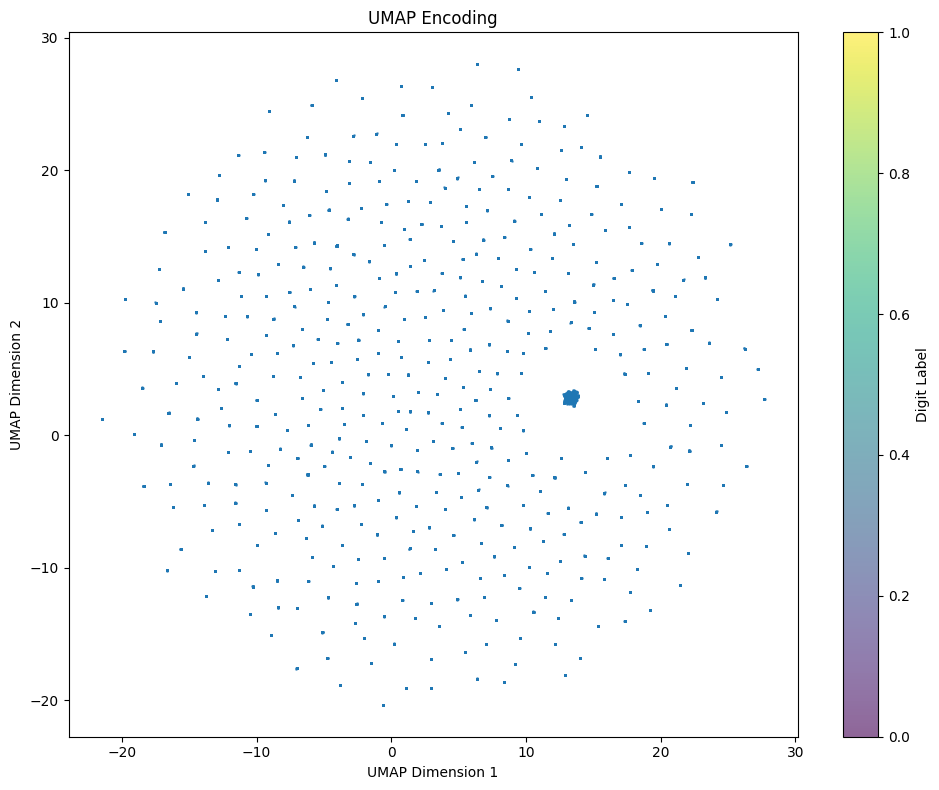

In [65]:
X = cat_cell_features(
    feature_types=["transcriptomics"],
    features=[tf],
    sample_size=len(resp)
)
y = np.array(resp)

from umap import UMAP
import matplotlib.pyplot as plt
umap = UMAP()
# umap = UMAP(n_neighbors=5, min_dist=0.01, random_state=42)
# Fit and transform the data
X_train_umap = umap.fit_transform(X)

# Plot the results
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_train_umap[:, 0], X_train_umap[:, 1], cmap="Spectral", s=1, alpha=0.6)
plt.colorbar(scatter, label="Digit Label")
plt.title("UMAP Encoding")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
# Show the plot
plt.tight_layout()
plt.show()

/home/dzhao268/anaconda3/envs/hdp/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


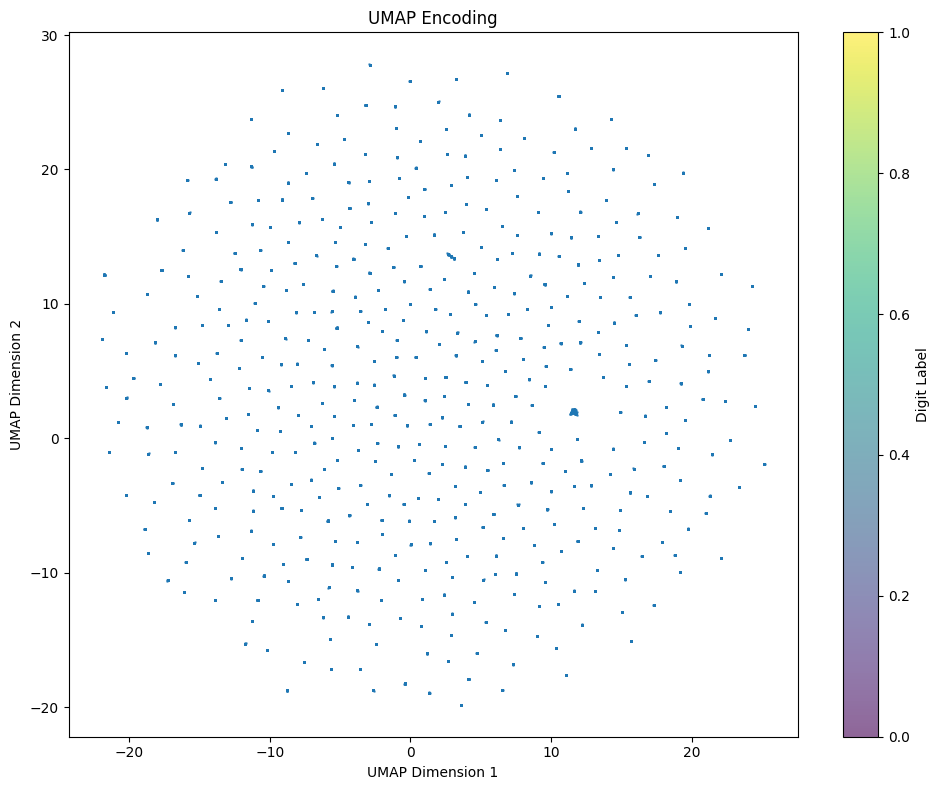

In [66]:
X = cat_cell_features(
    feature_types=["copy_number"],
    features=[cf],
    sample_size=len(resp)
)
y = np.array(resp)

from umap import UMAP
import matplotlib.pyplot as plt
umap = UMAP()
# umap = UMAP(n_neighbors=5, min_dist=0.01, random_state=42)
# Fit and transform the data
X_train_umap = umap.fit_transform(X)

# Plot the results
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_train_umap[:, 0], X_train_umap[:, 1], cmap="Spectral", s=1, alpha=0.6)
plt.colorbar(scatter, label="Digit Label")
plt.title("UMAP Encoding")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
# Show the plot
plt.tight_layout()
plt.show()

/home/dzhao268/anaconda3/envs/hdp/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


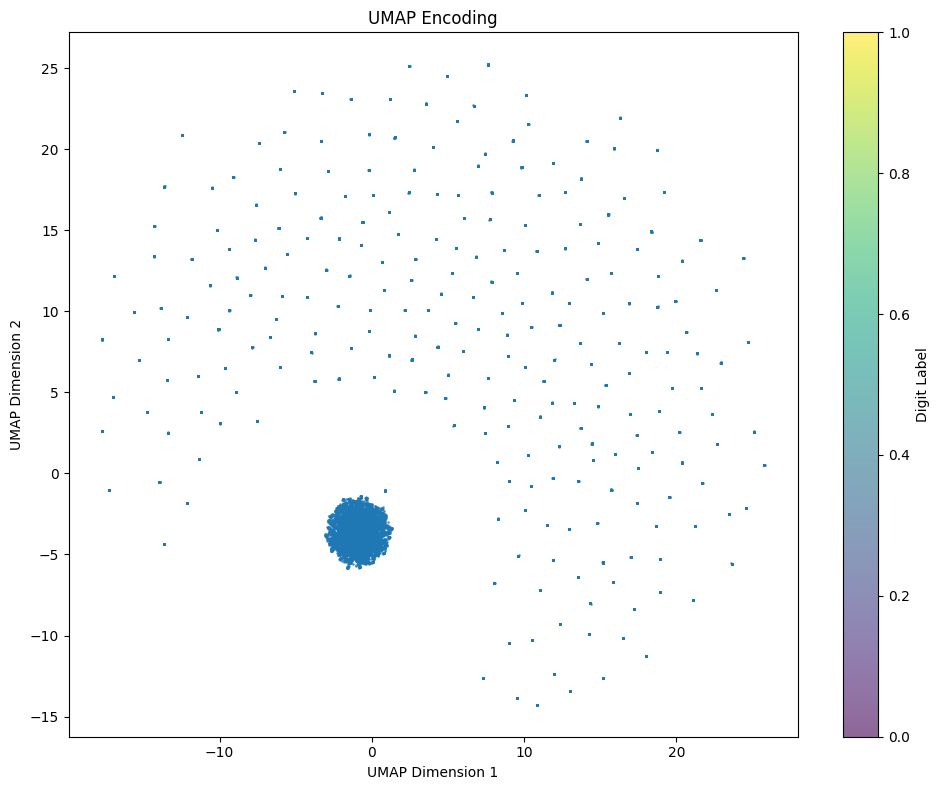

In [67]:
X = cat_cell_features(
    feature_types=["proteomics"],
    features=[pf],
    sample_size=len(resp)
)
y = np.array(resp)

from umap import UMAP
import matplotlib.pyplot as plt
umap = UMAP()
# umap = UMAP(n_neighbors=5, min_dist=0.01, random_state=42)
# Fit and transform the data
X_train_umap = umap.fit_transform(X)

# Plot the results
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_train_umap[:, 0], X_train_umap[:, 1], cmap="Spectral", s=1, alpha=0.6)
plt.colorbar(scatter, label="Digit Label")
plt.title("UMAP Encoding")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
# Show the plot
plt.tight_layout()
plt.show()